In [1]:
import torch
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
# from dask.distributed import Client

# ---------- Settings ----------

torch.manual_seed(0)
warnings.filterwarnings("ignore", message="Port 8787 is already in use")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- Client ----------

# client = Client(n_workers=1, threads_per_worker=8, memory_limit='120GB')
# print("Copy to dashboard:", client.dashboard_link)

Device: cuda


In [2]:
# ------------------------------
# Set up training & testing data
# ------------------------------

X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_hist_buffer.nc').X.values
Y = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_hist_buffer.nc').Y.values

X = np.swapaxes(X, 1, 2)
X.shape, Y.shape

((10, 1032, 5, 21, 51), (10, 1032, 1, 200, 501))

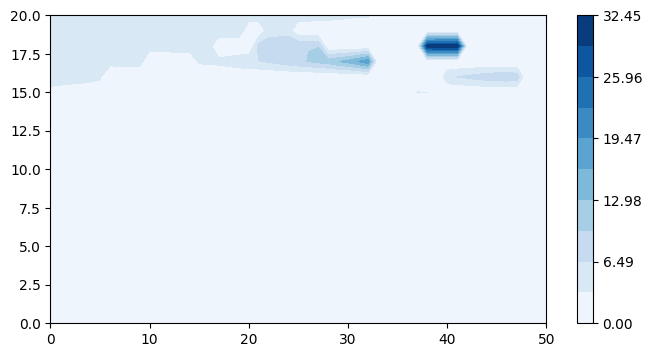

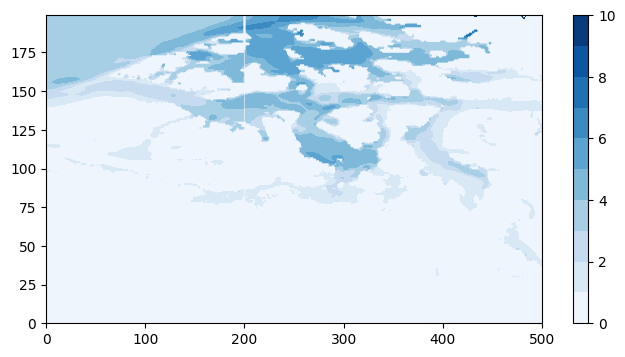

In [3]:
plt.figure(figsize=(8, 4))
plt.contourf(X[0, 0, 0], levels=np.linspace(0, X[0, 0, 0].max(), 11), cmap='Blues')
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 4))
plt.contourf(Y[0, 0, 0], levels=np.linspace(0, 10, 11), cmap='Blues')
plt.colorbar()
plt.show()

In [4]:
# ------------------------------
# Patch Extraction
# ------------------------------

def extract_patches(X, Y, low_patch_size=16, stride=8):

    patches_X = []
    patches_Y = []

    N, C, H, W = X.shape
    _, _, Hh, Wh = Y.shape

    if H < low_patch_size or W < low_patch_size:
        raise ValueError(f"Patch size {low_patch_size} too large for input ({H}, {W})")

    scale_y = Hh // H
    scale_x = Wh // W

    for n in range(N):
        for i in range(0, H-low_patch_size+1, stride):
            for j in range(0, W-low_patch_size+1, stride):

                x_patch = X[n, :, i:i+low_patch_size, j:j+low_patch_size]

                scale_i = i * scale_y
                scale_j = j * scale_x

                x_hi = low_patch_size * scale_y
                y_hi = low_patch_size * scale_x

                y_patch = Y[n, :, scale_i:scale_i+x_hi, scale_j:scale_j+y_hi]

                patches_X.append(x_patch)
                patches_Y.append(y_patch)

    return torch.stack(patches_X), torch.stack(patches_Y)


# ------------------------------
# Train/Test Split
# ------------------------------

N, T, C, H, W = X.shape

X_fields = torch.tensor(X.reshape(N*T, C, H, W)).float()
Y_fields = torch.tensor(Y.reshape(N*T, 1, Y.shape[3], Y.shape[4])).float()

indices = torch.randperm(N*T)
split = int(0.7*N*T)

train_idx = indices[:split]
test_idx = indices[split:]

X_train_fields = X_fields[train_idx]
Y_train_fields = Y_fields[train_idx]
X_test_fields = X_fields[test_idx]
Y_test_fields = Y_fields[test_idx]

# ------------------------------
# Normalize
# ------------------------------

X_mean = X_train_fields.mean(dim=(0, 2, 3), keepdim=True)
X_std = X_train_fields.std(dim=(0, 2, 3), keepdim=True)
Y_mean = Y_train_fields.mean(dim=(0, 2, 3), keepdim=True)
Y_std = Y_train_fields.std(dim=(0, 2, 3), keepdim=True)

X_train_fields = (X_train_fields - X_mean) / (X_std + 1e-6)
X_test_fields = (X_test_fields - X_mean) / (X_std + 1e-6)
Y_train_fields = (Y_train_fields - Y_mean) / (Y_std + 1e-6)
Y_test_fields = (Y_test_fields - Y_mean) / (Y_std + 1e-6)

# ------------------------------
# Extract Patches
# ------------------------------

X_train, Y_train = extract_patches(X_train_fields, Y_train_fields)
X_test, Y_test = extract_patches(X_test_fields, Y_test_fields)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: torch.Size([36120, 5, 16, 16])
Y_train: torch.Size([36120, 1, 144, 144])
X_test: torch.Size([15480, 5, 16, 16])
Y_test: torch.Size([15480, 1, 144, 144])


In [5]:
# ------------------------------
# Super Resolution CNN
# ------------------------------

class SuperResCNN(nn.Module):

    def __init__(self, in_channels, X_mean, X_std, Y_mean, Y_std):
        super().__init__()

        self.register_buffer("X_mean", X_mean)
        self.register_buffer("X_std", X_std)
        self.register_buffer("Y_mean", Y_mean)
        self.register_buffer("Y_std", Y_std)

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 32, 3, padding=1)
        self.conv5 = nn.Conv2d(32, 1, 3, padding=1)

    def cnn(self, x):
        r1 = self.relu(self.conv1(x))
        r2 = self.relu(self.conv2(r1))
        r3 = self.relu(self.conv3(r2)) + r2
        r4 = self.relu(self.conv4(r3))
        out = self.conv5(r4)
        return out

    def forward(self, x, up_size):

        base = F.interpolate(x[:, 0:1], size=up_size, mode="bilinear", align_corners=False)
        base_phys = base * self.X_std[:, 0:1] + self.X_mean[:, 0:1]
        base = (base_phys - self.Y_mean) / self.Y_std

        residual = self.cnn(x)
        residual = F.interpolate(residual, size=up_size, mode="bilinear", align_corners=False)

        return base + 0.1 * residual


# ------------------------------
# Model Setup
# ------------------------------

model = SuperResCNN(
    in_channels=X_train.shape[1],
    X_mean=X_mean,
    X_std=X_std,
    Y_mean=Y_mean,
    Y_std=Y_std,
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
# criterion = nn.MSELoss()
# criterion = nn.L1Loss()
criterion = lambda y_pred, y_true: (
    0.7 * nn.functional.l1_loss(y_pred, y_true)
    + 0.3 * nn.functional.mse_loss(y_pred, y_true)
)

print("Done!")

Done!


Epoch 1/25 | Loss: 0.192838
Epoch 2/25 | Loss: 0.159515
Epoch 3/25 | Loss: 0.150888
Epoch 4/25 | Loss: 0.146227
Epoch 5/25 | Loss: 0.143593
Epoch 6/25 | Loss: 0.141660
Epoch 7/25 | Loss: 0.140345
Epoch 8/25 | Loss: 0.139316
Epoch 9/25 | Loss: 0.138591
Epoch 10/25 | Loss: 0.137950
Epoch 11/25 | Loss: 0.137439
Epoch 12/25 | Loss: 0.137063
Epoch 13/25 | Loss: 0.136677
Epoch 14/25 | Loss: 0.136401
Epoch 15/25 | Loss: 0.136187
Epoch 16/25 | Loss: 0.135907
Epoch 17/25 | Loss: 0.135608
Epoch 18/25 | Loss: 0.135413
Epoch 19/25 | Loss: 0.135215
Epoch 20/25 | Loss: 0.135102
Epoch 21/25 | Loss: 0.134872
Epoch 22/25 | Loss: 0.134666
Epoch 23/25 | Loss: 0.134517
Epoch 24/25 | Loss: 0.134315
Epoch 25/25 | Loss: 0.134168


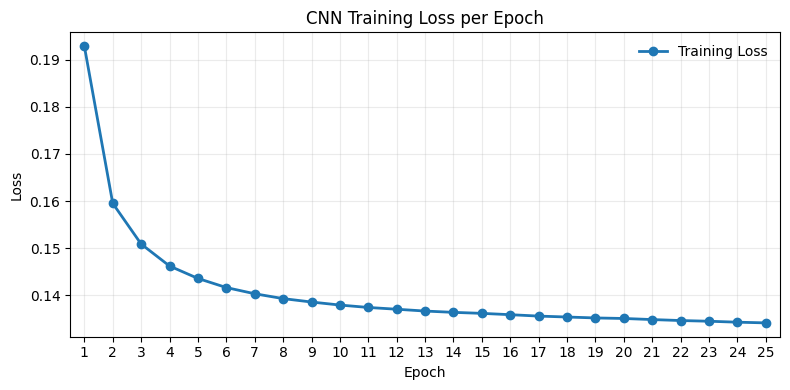

In [6]:
# ------------------------------
# Training Loop
# ------------------------------

num_epochs = 25
batch_size = 16
loss_array = []

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0

    idx = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), batch_size):

        optimizer.zero_grad()

        batch_idx = idx[i:i+batch_size]
        X_batch = X_train[batch_idx].to(device, non_blocking=True)
        Y_batch = Y_train[batch_idx].to(device, non_blocking=True)

        Y_pred = model(X_batch, Y_batch.shape[-2:])
        loss = criterion(Y_pred, Y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

        # Clean up after loop
        del X_batch, Y_batch, Y_pred, loss

    epoch_loss /= X_train.size(0)
    loss_array.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.6f}")


epochs = np.arange(1, len(loss_array)+1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_array, marker='o', linestyle='-', color='C0', linewidth=2, markersize=6, label='Training Loss')

plt.title('CNN Training Loss per Epoch', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.xticks(epochs)
plt.xlim(0.5, len(epochs)+0.5)
plt.grid(alpha=0.25)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [7]:
# ------------------------------
# Evaluation
# ------------------------------
model.eval()
batch_size = 16
preds = []

with torch.inference_mode():
    for i in range(0, X_test.shape[0], batch_size):

        X_batch = X_test[i:i+batch_size].to(device)
        Y_batch = Y_test[i:i+batch_size]

        Y_pred_batch = model(X_batch, Y_batch.shape[-2:])
        preds.append(Y_pred_batch.cpu())

Y_pred = torch.cat(preds, dim=0)
Y_pred_phys = Y_pred * Y_std + Y_mean
Y_test_phys = Y_test * Y_std + Y_mean

# ------------------------------
# Bilinear baseline
# ------------------------------
sit_idx = 0

X_test_sit_phys = (
    X_test[:, sit_idx:sit_idx+1] * X_std[:, sit_idx:sit_idx+1]
    + X_mean[:, sit_idx:sit_idx+1]
)

base = F.interpolate(
    X_test_sit_phys,
    size=Y_test.shape[-2:],
    mode="bilinear",
    align_corners=False
)

# ------------------------------
# Metrics
# ------------------------------
mse_cnn = ((Y_pred_phys - Y_test_phys)**2).mean().item()
mse_base = ((base - Y_test_phys)**2).mean().item()


def spatial_corr(y_true, y_pred):
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)

    corrs = []
    valid = 0
    total = y_true.shape[0]

    for i in range(y_true.shape[0]):

        std_true = np.std(y_true_flat[i])
        std_pred = np.std(y_pred_flat[i])

        # Skip bad patches
        if std_true > 0 and std_pred > 0:
            valid += 1
            corrs.append(np.corrcoef(y_true_flat[i], y_pred_flat[i])[0, 1])

    print(f"Valid patches: {valid}/{total}")

    return np.nanmean(corrs)


corr_cnn = spatial_corr(
    Y_test_phys.cpu().numpy(),
    Y_pred_phys.cpu().numpy()
)

corr_base = spatial_corr(
    Y_test_phys.cpu().numpy(),
    base.cpu().numpy()
)

print(f"\nCNN Test MSE         : {mse_cnn:.4f}")
print(f"Bilinear baseline MSE: {mse_base:.4f}")
print(f"\nCNN Test spatial correlation         : {corr_cnn:.4f}")
print(f"Bilinear baseline spatial correlation: {corr_base:.4f}")

Valid patches: 15480/15480
Valid patches: 15480/15480

CNN Test MSE         : 0.2422
Bilinear baseline MSE: 0.7773

CNN Test spatial correlation         : 0.8239
Bilinear baseline spatial correlation: 0.2787


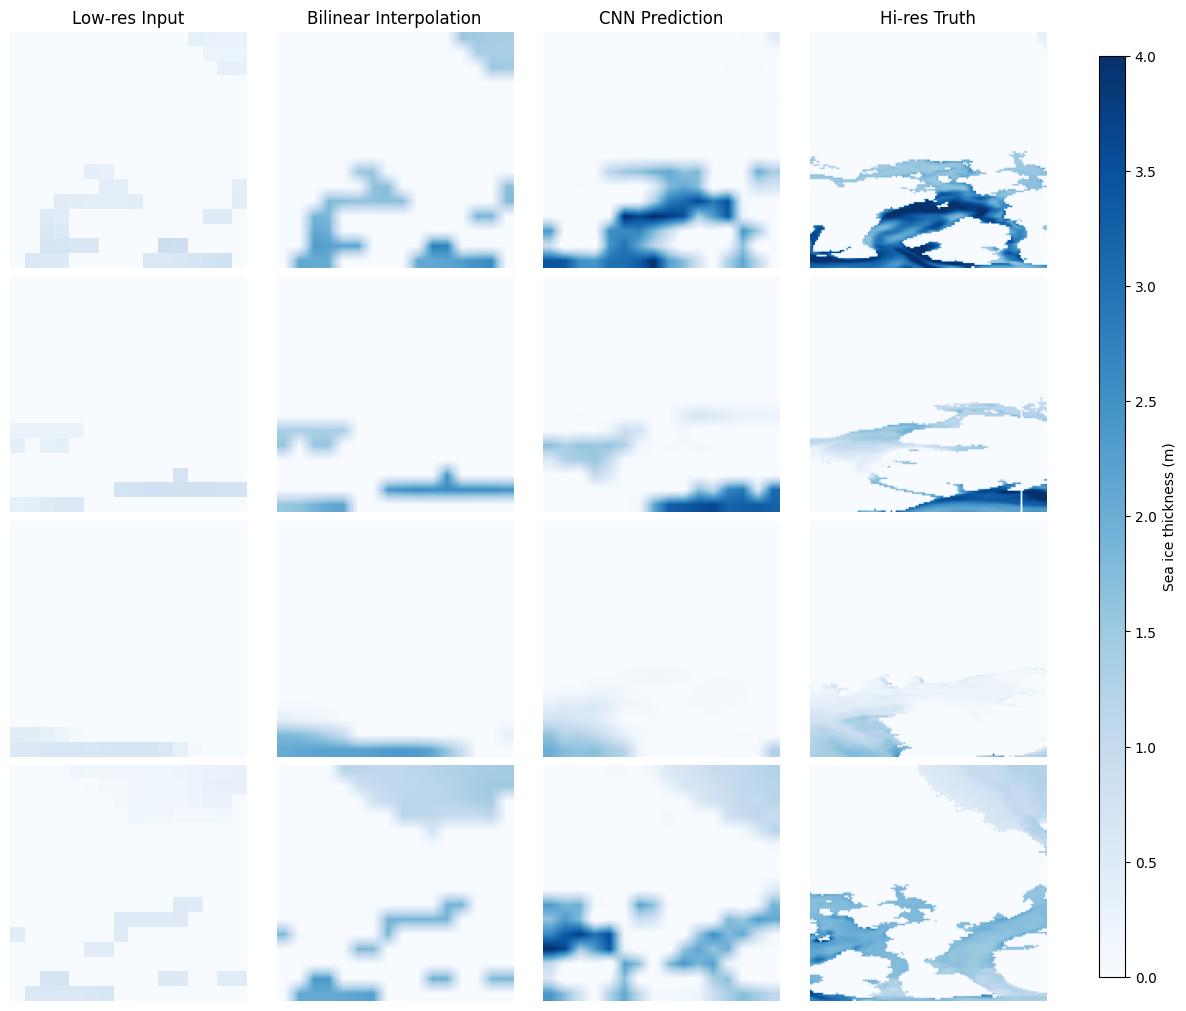

In [11]:
# ------------------------------
# Random samples for plotting
# ------------------------------
num_samples = 4
idxs = np.random.choice(X_test.shape[0], num_samples, replace=False)
cmap = 'Blues'
vmin, vmax = 0, 4

fig, axs = plt.subplots(num_samples, 4, figsize=(12, 10), constrained_layout=True)

for i, idx in enumerate(idxs):
    axs[i, 0].imshow(X_test[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 1].imshow(base[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 2].imshow(Y_pred_phys[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 3].imshow(Y_test_phys[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    for j in range(4):
        axs[i, j].axis('off')

axs[0, 0].set_title("Low-res Input")
axs[0, 1].set_title("Bilinear Interpolation")
axs[0, 2].set_title("CNN Prediction")
axs[0, 3].set_title("Hi-res Truth")

fig.colorbar(axs[0, 0].images[0], ax=axs, shrink=0.95, aspect=35, label='Sea ice thickness (m)')
plt.show()

### Ideas

- Idea 1: Train on only informative patches -> Tried

```
mask = Y_patches.mean(dim=(2, 3)) > 0.05
X_patches = X_patches[mask]
Y_patches = Y_patches[mask]
```

- Idea 2: Weight the loss by ice presence/ice edge

```
ice_mask = (Y_true > 0)
loss_new = ((Y_pred - Y_true)**2 * (1 + ice_mask)).mean()

def edge_weight(y):
    dy = torch.abs(y[:, :, 1:, :] - y[:, :, :-1, :])
    dx = torch.abs(y[:, :, :, 1:] - y[:, :, :, :-1])
    return 1 + 5 * (F.pad(dx, (0,1,0,0)) + F.pad(dy, (0,0,0,1)))

weights = edge_weight(Y_true)
loss = (weights * (Y_pred - Y_true)**2).mean()
```

- Idea 3: Add ice presence as input channel

- Idea 4: Add lat, lon as input channels

- Idea 5: Add skip connection(s): ```r3 = self.relu(self.conv3(r2)) + r2``` -> Didn't seem to change much

- Idea 6: Gradient loss -> Done, no noticeable difference

Replace ```criterion = nn.MSELoss()``` with: 

```
def gradient_loss(y_pred, y_true):
    dy_pred = torch.abs(y_pred[:, :, 1:, :] - y_pred[:, :, :-1, :])
    dx_pred = torch.abs(y_pred[:, :, :, 1:] - y_pred[:, :, :, :-1])

    dy_true = torch.abs(y_true[:, :, 1:, :] - y_true[:, :, :-1, :])
    dx_true = torch.abs(y_true[:, :, :, 1:] - y_true[:, :, :, :-1])

    return ((dx_pred - dx_true)**2).mean() + ((dy_pred - dy_true)**2).mean()


criterion = lambda y_pred, y_true: (
    nn.functional.mse_loss(y_pred, y_true)
    + 0.1 * gradient_loss(y_pred, y_true)
)
```

- Idea 7: Increase patch size -> Done, works

- Idea 8: Predict residual explicitly as target -> Does not work

We have:
```
output = base + residual
loss(output, truth)
```

Let's do:
```
target_residual = Y_train - base
loss(residual_pred, target_residual)
```

Implement:
```
# Compute baseline (normalized space)
base = F.interpolate(
    X_batch[:, 0:1],
    size=Y_batch.shape[-2:],
    mode="bilinear",
    align_corners=False
)

base_phys = base * self.X_std[:, 0:1] + self.X_mean[:, 0:1]
base = (base_phys - self.Y_mean) / self.Y_std

target_residual = Y_batch - base

pred_residual = model.cnn(X_batch)
pred_residual = F.interpolate(pred_residual, size=Y_batch.shape[-2:], mode="bilinear", align_corners=False)

loss = criterion(pred_residual, target_residual)
```